In [16]:
import numpy as np
import bacco
import matplotlib.pyplot as plt

In [53]:
%load_ext autoreload
%autoreload 2

In [101]:
import sys
sys.path.append("/cosmos_storage/home/fgmaion/MTNG-resims/src")
import utils

In [79]:
def plot_comparison(zoom, mtng, indices, final_sel):
    M1 = 1e10 * zoom.fof['halo_m200b'][indices['ind']]
    M2 = 1e10 * mtng.fof['halo_m200b'][final_sel]

    pos1 = zoom.fof['halo_pos'][indices['ind']]
    pos2 = mtng.fof['halo_pos'][final_sel].T

    mfof = zoom.fof['halo_mfof_type']
    hd = mfof[:,0] + mfof[:,1] + mfof[:,4] + mfof[:,5]
    lr = mfof[:,2] + mfof[:,3]
    f_all = lr / (hd + lr)         # shape (N_zoom_halos,)
    f_contam = f_all[indices['ind']]           # shape (N_targets, k), matches d_m

    fig, ax = plt.subplots(2, 2, dpi=200, figsize=(11,10))

    ax[0,0].set_xscale('log')
    ax[0,1].set_xscale('log')
    ax[1,0].set_xscale('log')
    ax[1,1].set_xscale('log')
    ax[1,1].set_yscale('log')

    ax[0,0].plot(M2, M1/M2, ls='', marker='o')
    ax[0,1].plot(M2, indices['d'], ls='', marker='o')
    ax[1,0].plot(M2, f_contam, ls='', marker='o')
    ax[1,1].plot(M2, M1, ls='', marker='o')

    return 0

In [136]:
base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/"

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

snap = 264
zoom = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap), dm_file="snapdir_{:03d}/snapshot_{:03d}".format(snap,snap), sim_format='TNG500', fixedPk=True, use_orphans=False,\
                        tau=tau, ns=ns, sigma8=sigma8, tree_file="groups_{:03d}/subhalo_prog_{:03d}".format(snap,snap), numpart=4320**3, use_ids=True)

print(zoom.header['Redshift'])

2026-05-12 18:15:58,793 bacco.sims : Initialising simulation Default
2026-05-12 18:15:58,794 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264
2026-05-12 18:15:58,796 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264
2026-05-12 18:15:58,802 bacco.sims : ...done in 0.00948 s


4.440892098500626e-16


In [99]:
zoom.fof['halo_vel']

(139956, 3)

In [4]:
mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/TNG_Family/MTNG/", snap=snap)
mtng.fof['halo_pos'][:,0] = (mtng.fof['halo_pos'][:,0] - 125) % 500
mtng.sub['pos'][:,0] = (mtng.sub['pos'][:,0] - 125) % 500

print(mtng.header['Redshift'])

2026-05-11 21:05:54,514 bacco.sims : Initialising simulation Default
2026-05-11 21:05:54,515 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2026-05-11 21:05:54,517 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2026-05-11 21:05:54,523 bacco.sims : ...done in 0.00952 s
2026-05-11 21:05:54,528 bacco.sims : Reading 98233510 items for GroupPos
2026-05-11 21:05:58,972 bacco.sims : Reading 90246895 items for SubhaloPos


4.440892098500626e-16


In [7]:
with open("/cosmos_storage/home/fgmaion/MTNG-resims/halo_selection/hydro_halo_sel_1pmbin.txt") as f:
    final_sel = []

    for line in f.readlines():
        final_sel.append(int(line.split()[0]))

final_sel = np.array(final_sel)

In [86]:
ind = np.load("/cosmos_storage/home/fgmaion/MTNG-resims/halo_selection/cross_match_fiducial.npy", allow_pickle=True).item()

In [24]:
M1 = 1e10 * zoom.fof['halo_m200b'][ind['ind']]
M2 = 1e10 * mtng.fof['halo_m200b'][final_sel]

pos1 = zoom.fof['halo_pos'][ind['ind']]
pos2 = mtng.fof['halo_pos'][final_sel].T

0

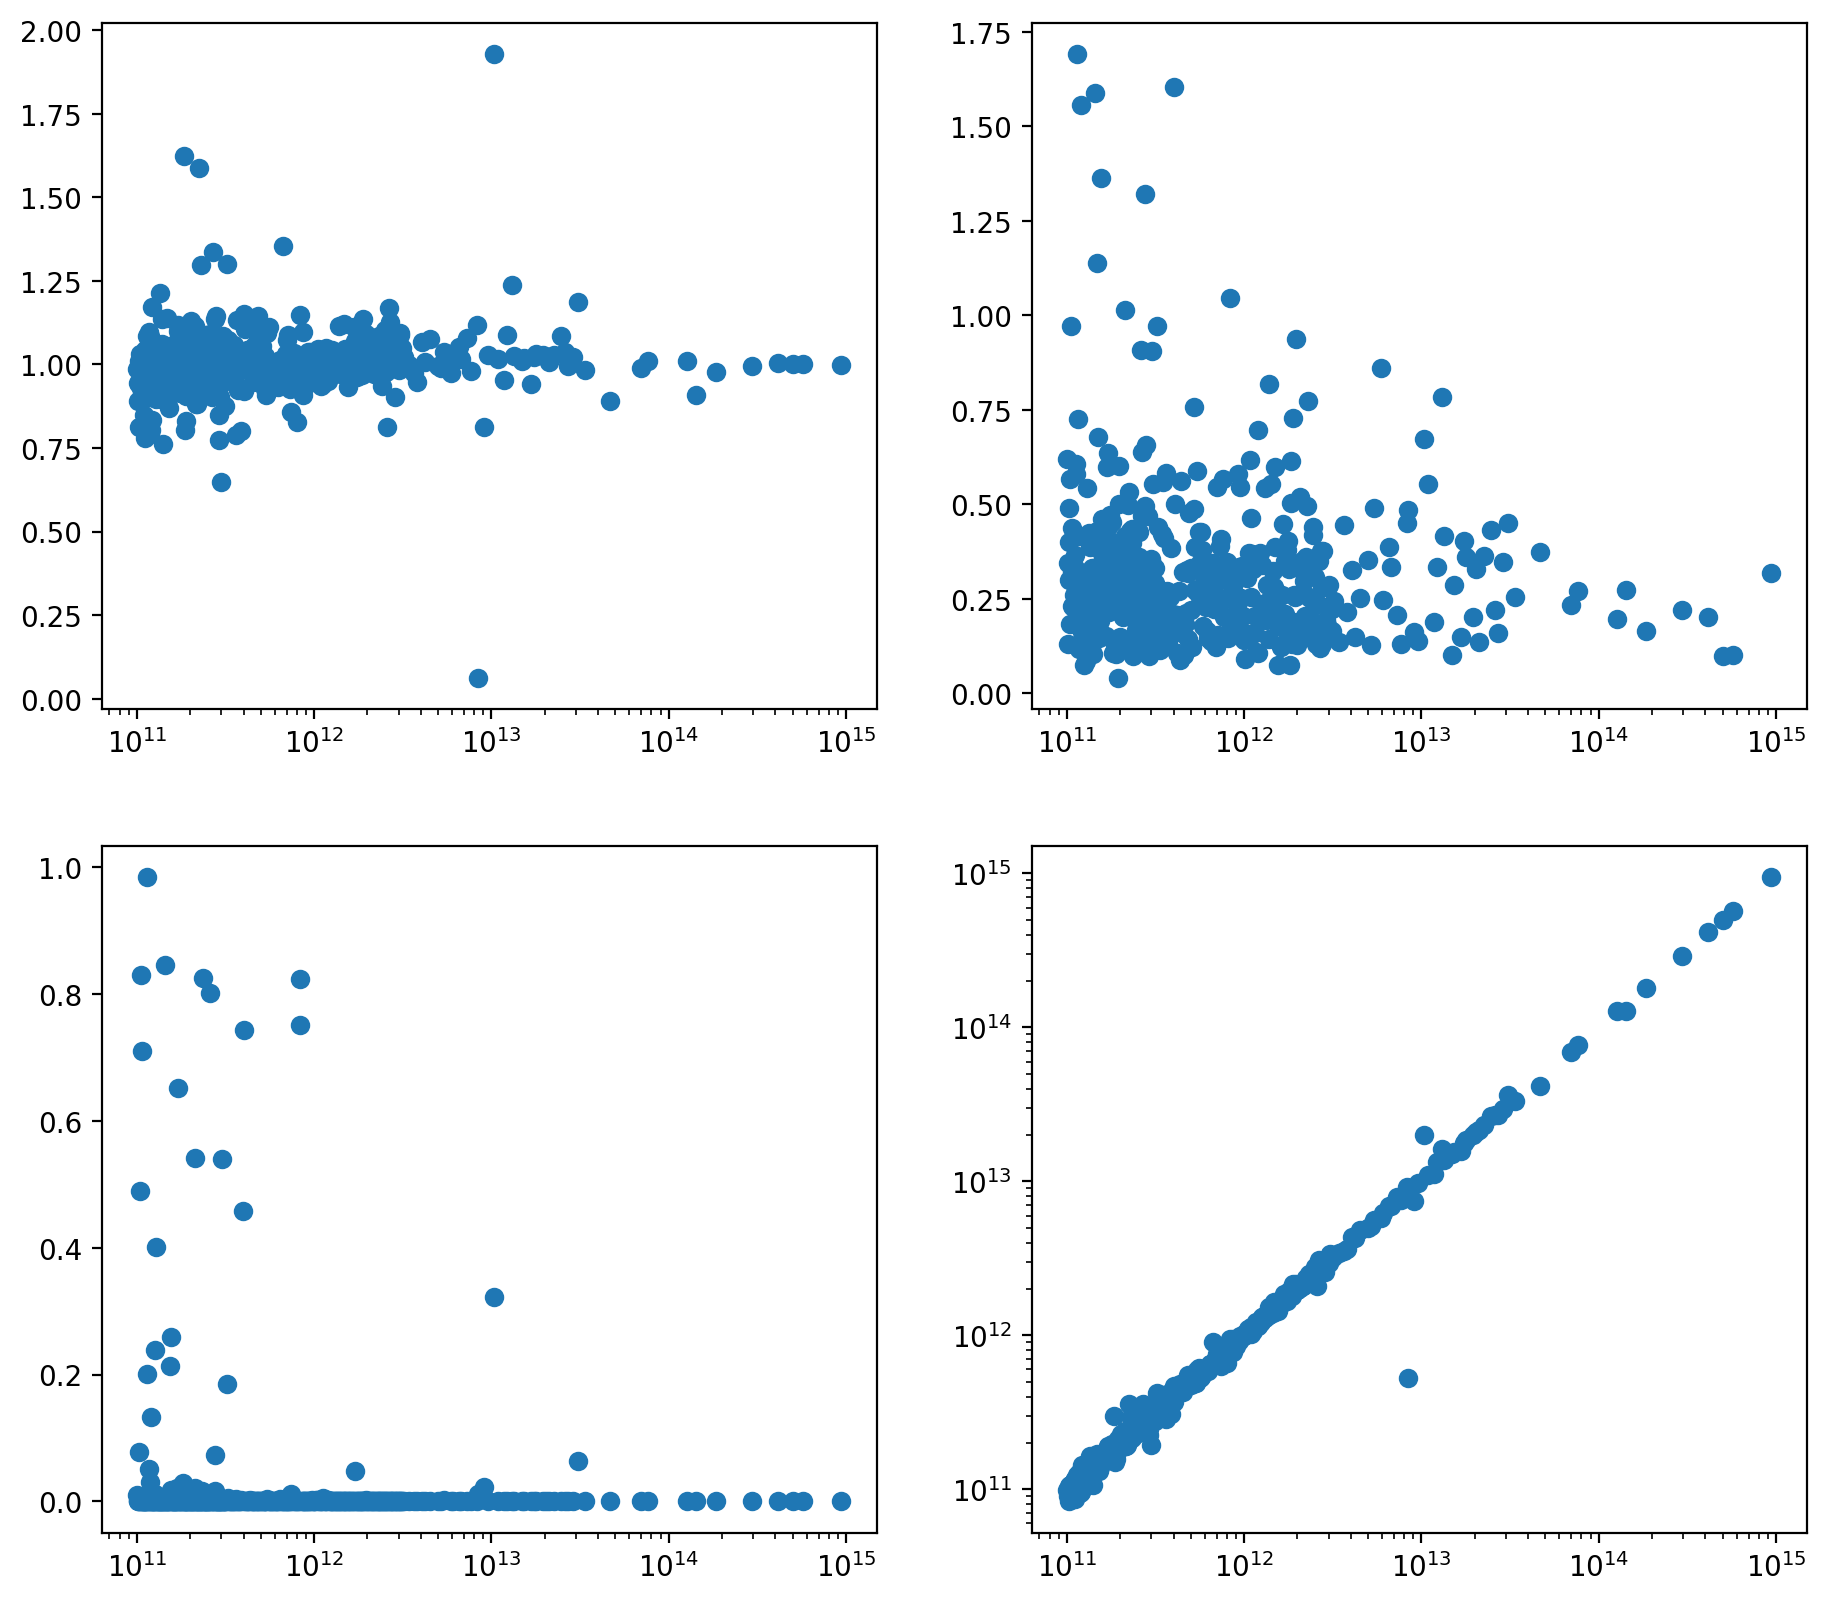

In [87]:
plot_comparison(zoom, mtng, ind, final_sel)

In [95]:
xmatch = np.load("/cosmos_storage/home/fgmaion/MTNG-resims/cross-match/cross_match_fiducial.npy", allow_pickle=True).item()

In [137]:
xmatch_2 = utils.cross_match(zoom, snap=264, name=None)

2026-05-12 18:16:02,734 bacco.sims : Initialising simulation Default
2026-05-12 18:16:02,736 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2026-05-12 18:16:02,737 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2026-05-12 18:16:02,743 bacco.sims : ...done in 0.00914 s
2026-05-12 18:16:02,749 bacco.sims : Reading 98233510 items for GroupPos


2026-05-12 18:16:08,697 bacco.sims : Reading 90246895 items for SubhaloPos
2026-05-12 18:16:13,290 bacco.sims : Reading 139956 items for GroupPos
2026-05-12 18:16:13,362 bacco.sims : Reading 139956 items for Group_M_Mean200
2026-05-12 18:16:13,379 bacco.sims : Reading 98233510 items for Group_M_Mean200
2026-05-12 18:16:15,068 bacco.sims : Reading 139956 items for GroupVel
2026-05-12 18:16:15,086 bacco.sims : Reading 98233510 items for GroupVel
/cosmos_storage/home/fgmaion/MTNG-resims/src/utils.py:1128: RuntimeWarning: divide by zero encountered in divide
  d_m = np.abs((1 - m1[..., np.newaxis]/m2) / 0.2)


2026-05-12 18:16:18,793 bacco.sims : Reading 139956 items for GroupMassType


0

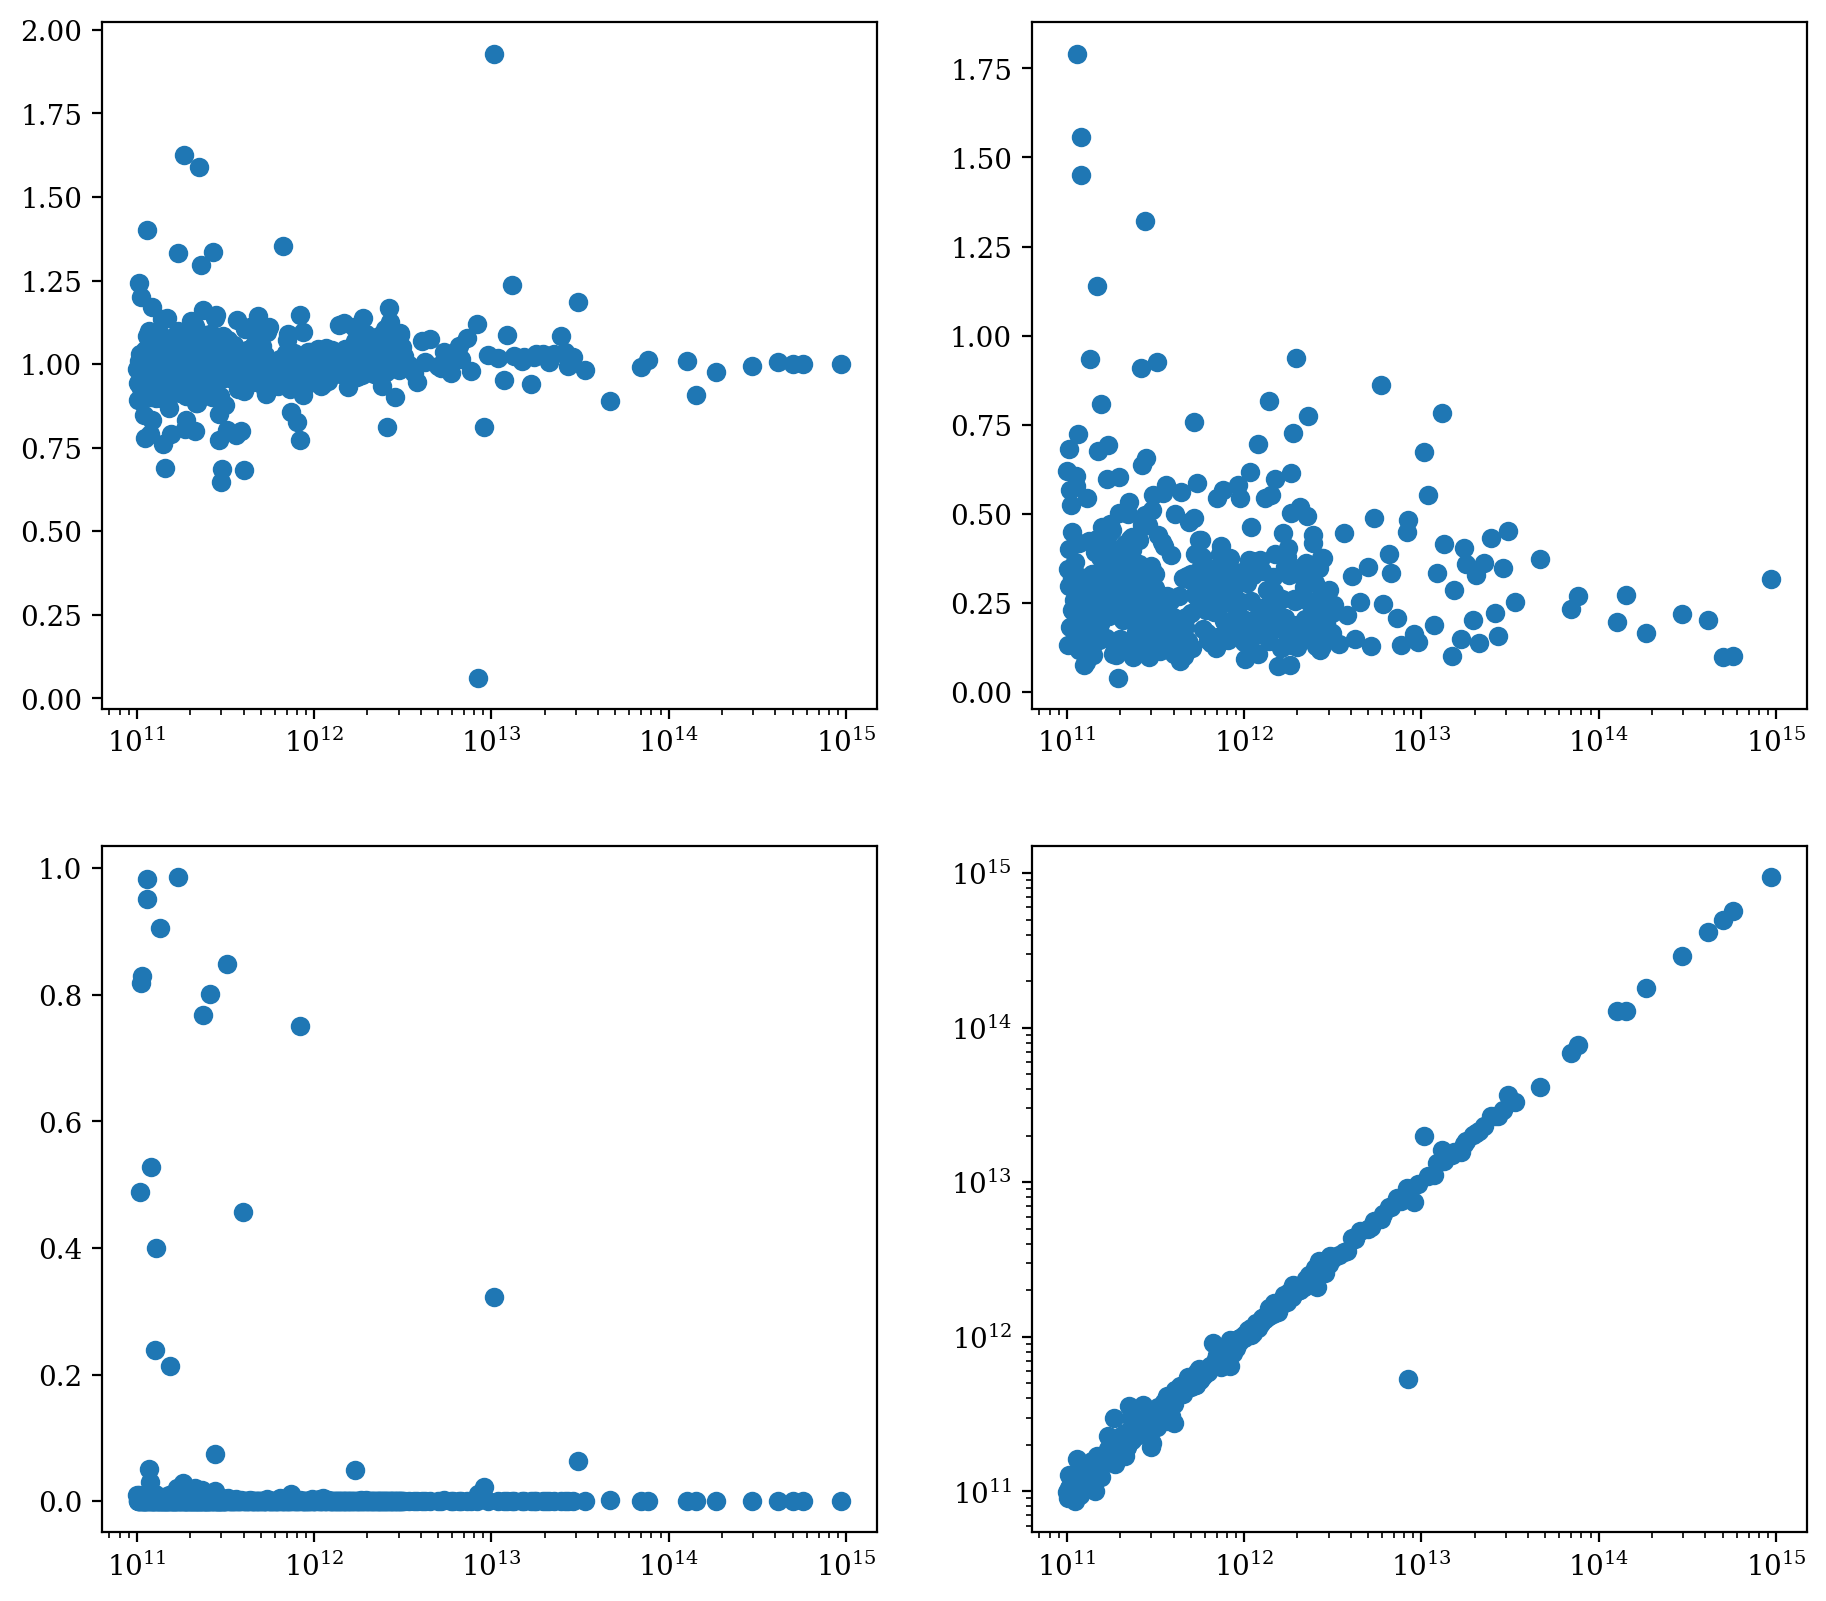

In [138]:
plot_comparison(zoom, mtng, xmatch_2, final_sel)